In [17]:
#Importing modules
import numpy as np
import matplotlib.pyplot as plt
from fonction import trapezeVect, Dp, Da, Dl

In [26]:
#definition of constants
c = 3e5
H0 = 67.36
h = H0/100
wp = 2.47e-5
wn = 1.7e-5
wr = wp+wn
wm = 0.14240
wL = h**2-(wm+wr)

Changes in the various densities and H as a function of z, in order to visualize which components dominate the universe as a function of redshift.

In [31]:
z1 = np.logspace(-1,5,10000)
OMl = np.ones_like(z1) * 0.6889
OMm = 0.3111*(1+z1)**3
OMp = 5.44e-5
OMn = 3.69e-5
OMr = (OMp+OMn)*(1+z1)**4
H = 100*np.sqrt(wm*(1+z1)**3+wr*(1+z1)**4+wL)
zrm = (wm/wr)-1
zmL = (wL/wm)**(1/3)-1

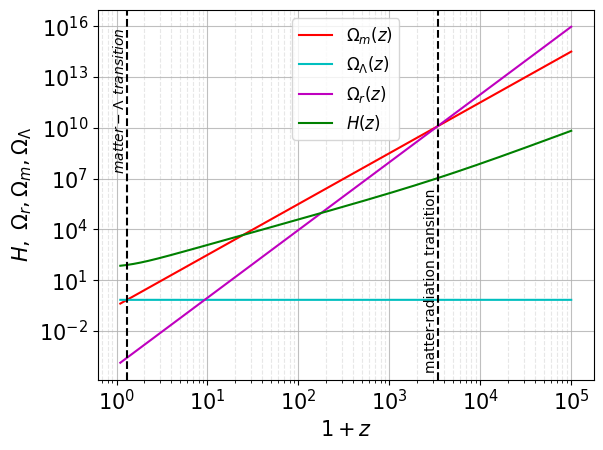

In [32]:
plt.figure()
plt.plot(z1+1,OMm,'r', label=r"$\Omega_{m}(z)$")
plt.plot(z1+1,OMl,'c',label=r"$\Omega_{\Lambda}(z)$")
plt.plot(z1+1,OMr, 'm',label=r"$\Omega_{r}(z)$")
plt.plot(z1+1,H,'g',label=r"$H(z)$")
plt.xlabel(r"$1+z$", fontsize=15)
plt.ylabel(r"$H,\;\Omega_{r},\Omega_{m},\Omega_{\Lambda}$", fontsize=15)
plt.legend(fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.axvline(x=zrm+1, color='k', linestyle='--')
plt.text(zrm+1,plt.gca().get_ylim()[0]+0.00002,'matter-radiation transition',rotation=90, va='bottom', ha='right',color='k')
plt.axvline(x=zmL+1, color='k', linestyle='--')
plt.text(zmL+1,plt.gca().get_ylim()[1] * 0.1, r'$matter-\Lambda \:\:transition$',rotation=90, va='top', ha='right',color='k')
plt.grid(which="major", alpha=0.8)
plt.grid(which="minor", alpha=0.3, linestyle="--")
#plt.savefig("plot_densite(z)_H(z).pdf", dpi=300)
plt.show()

Calculation of distances based on redshift

In [33]:
z = np.linspace(0,10,100)
def inv_H(r):
    H = 100 * np.sqrt(wm * (1 + r) ** 3 + wr * (1 + r) ** 4 + wL)
    return 1.0 / H
w0 = -1
wa = 0
def H2(r) :
	return 1/np.sqrt(H0p**2*(0.31*(1+r)**3+5e-5*(1+r)**4+0.683*(1+z)**(3*(1+w0+wa))*np.exp(-3*wa*z/(1+z))))
a = 0 #lower terminal
b = z #upper limit
n = 500 # number of subdivisions

In [34]:
#Calculating distances
chi_vals = []  #Comoving distance
Da_vals = []  #Angular distance
Dl_vals = []  #Luminosity distance

for zi in z:
    integral = trapezeVect(inv_H, 0, zi, n)
    chi_Mpc = c * integral
    da_Mpc = chi_Mpc / (1 + zi)
    dl_Mpc = chi_Mpc * (1 + zi)
    chi_vals.append(chi_Mpc / 1000)
    Da_vals.append(da_Mpc / 1000)
    Dl_vals.append(dl_Mpc / 1000)
chi_vals = np.array(chi_vals)
Da_vals = np.array(Da_vals)
Dl_vals = np.array(Dl_vals)

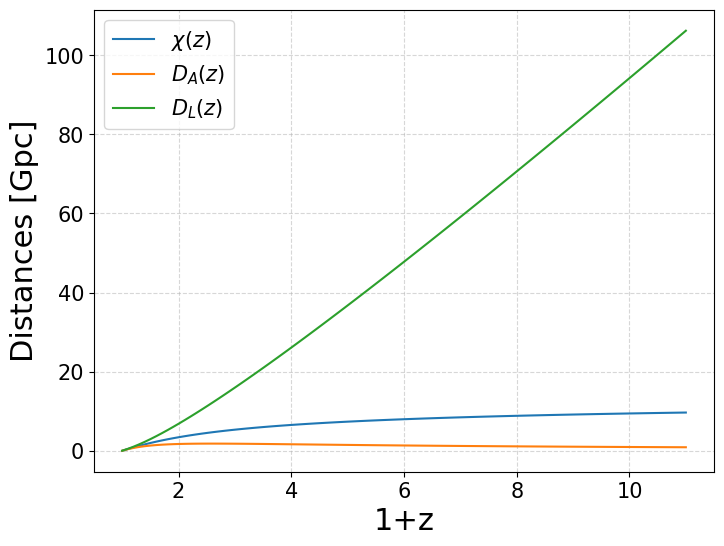

In [35]:
#creation of a distance plot based on 1+Z
plt.figure(figsize=(8, 6))
plt.plot(1 + z, chi_vals, label=r"$\chi(z)$")
plt.plot(1 + z, Da_vals, label=r"$D_A(z)$")
plt.plot(1 + z, Dl_vals, label=r"$D_L(z)$")

plt.xlabel("1+z", fontsize=22)
plt.ylabel("Distances [Gpc]", fontsize=22)
plt.legend(fontsize=15)
plt.grid(True, linestyle="--", alpha=0.5)
#plt.savefig("distance.pdf",dpi=300)
plt.show()

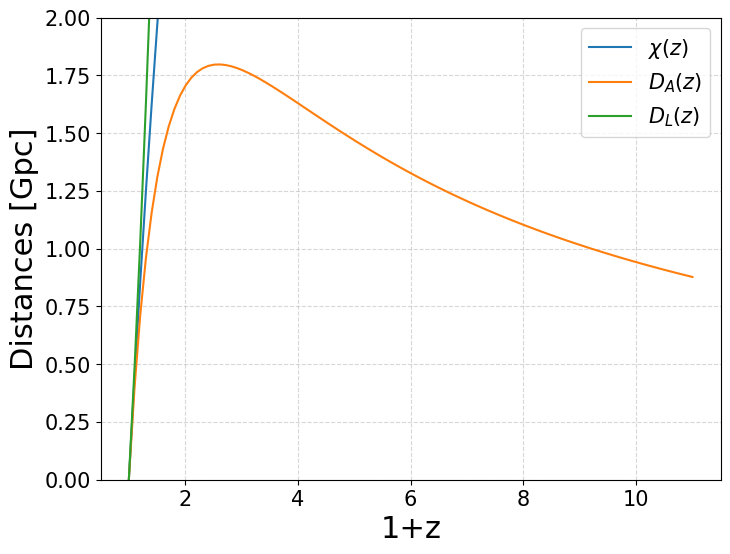

In [36]:
#Creation of a graph of distances as a function of 1+Z, zoomed in to show the decrease in angular distance
plt.figure(figsize=(8, 6))
plt.plot(1 + z, chi_vals, label=r"$\chi(z)$")
plt.plot(1 + z, Da_vals, label=r"$D_A(z)$")
plt.plot(1 + z, Dl_vals, label=r"$D_L(z)$")

plt.xlabel("1+z", fontsize=22)
plt.ylabel("Distances [Gpc]", fontsize=22)
plt.legend(fontsize=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0,2)
#plt.savefig("distance_zoom.pdf",dpi=300)
plt.show()